# 04 - Training Dataset Generation

Phase 7 (defining the ML problem) and Phase 8 (training-dataset creation) of
the project.

**The problem this notebook solves:** the product master dataset has real
prices for ~6,500 products, but there is no dataset anywhere of real
apartments with a known total finishing cost. Per the project rules, that
target is not fabricated -- instead this notebook builds a documented,
reproducible, scenario-generated training dataset using
`src/scenario_generation/generate_scenarios.py`. **Read that module's
docstring first** -- it is the full methodology write-up for how the target
is constructed. This notebook summarizes it, generates the dataset,
validates it, explores it, and performs the mandatory Phase 9 leakage
audit.

## 1. Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    raise RuntimeError("Could not locate project root from " + str(start))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

from src.config import PROCESSED_DATA_DIR, TRAINING_DATA_DIR, FIGURES_DIR, REPORTS_DIR, RANDOM_SEED
from src.scenario_generation.generate_scenarios import (
    generate_training_dataset, FEATURE_COLUMNS, CATEGORY_COST_COLUMNS,
)

master = pd.read_csv(PROCESSED_DATA_DIR / "master_products_features.csv")
master.shape

(6487, 46)

## 2. Methodology Summary (see the module docstring for full detail)

1. Sample `N` plausible apartment configurations (area, rooms, bathrooms,
   balconies, receptions, an overall Finishing_Level preference) from
   documented, hand-set distributions -- not fitted to any cost target.
2. For every apartment, resolve ~19 required/optional "line items" (e.g.
   "N interior doors", "wiring for the whole area", "WC + wash basin per
   bathroom", labor and auxiliary materials, ...). Each line item selects
   ONE real product at the requested quality tier and computes the
   quantity needed using **that product's own `Quantity_Rule` /
   `Rule_Value`** (+ `Coverage_m2` / `Coverage_m2_per_L` / `Coats` /
   `Waste_Factor` where relevant) -- vocabulary that already existed in the
   raw data.
3. Category costs = sum(quantity x price) per category. Total cost = sum of
   all category costs (incl. labor + auxiliary).

This is a **scenario-generated / synthetic** training dataset. It is
labeled as such everywhere it is used, per the project rules -- it is not
real observed apartment cost data.

## 3. Generate the Training Dataset

In [2]:
N_SCENARIOS = 6000  # documented choice: large enough for stable train/val/test splits

training_df = generate_training_dataset(master, n_scenarios=N_SCENARIOS, seed=RANDOM_SEED)
training_df.shape

(6000, 34)

In [3]:
training_df.head()

,Scenario_ID,Apartment_Area_m2,Rooms,Bathrooms,Master_Bathrooms,Balconies,Receptions,Finishing_Level,Reception_Area_m2,Bedroom_Area_m2,Paintable_Area_m2,Paints_Quality,Electrical_Basic_Quality,Flooring_Quality,Sanitary_Quality,Doors_Quality,Ceilings_Quality,Electrical_Finishing_Quality,Plumbing_Quality,Include_Reception_Ceiling_Upgrade,Include_Reception_Chandelier,Include_Master_Bathroom_Upgrade,Plumbing_System,Ceilings_Cost,Doors_Cost,Electrical_Basic_Cost,Electrical_Finishing_Cost,Flooring_Cost,Paints_Cost,Plumbing_Cost,Sanitary_Cost,Labor_Cost,Auxiliary_Cost,Total_Finishing_Cost_EGP
0,S000001,147.6,4,2,1,2,1,Low,51.7,95.9,442.8,Low,Medium,Medium,Medium,Low,Medium,Medium,Low,False,False,False,PPR Pipes,12300.000000,37336.0,40516.812,4296.0,60612.6,1695.521455,2460.0,20940.0,65922.0,28754.0,274832.93
1,S000002,125.8,3,1,1,1,1,Medium,44.0,81.8,377.4,Medium,Medium,Low,Medium,Medium,Medium,High,High,False,True,True,PVC Pipes,12448.958333,34046.0,36387.738,6432.0,51166.2,10212.444000,950.0,13643.0,43895.0,25473.0,234654.34
2,S000003,152.7,4,2,1,2,1,Medium,53.4,99.3,458.1,Medium,Medium,Medium,Medium,Medium,Medium,High,Medium,True,True,False,PVC Pipes,52266.875000,44177.0,42027.907,6778.0,64797.9,10783.674000,1600.0,18504.0,56992.5,32649.5,330577.36
3,S000004,100.2,3,2,1,1,1,Medium,35.1,65.1,300.6,Medium,Medium,Medium,Medium,Medium,Medium,High,Medium,True,True,False,PVC Pipes,32717.291667,32187.0,27896.952,6354.0,50232.6,9126.216000,1540.0,18458.0,41355.0,22937.0,242804.06
4,S000005,81.6,2,1,1,2,1,Medium,28.6,53.0,244.8,Medium,Medium,High,Low,Medium,High,Medium,Low,False,True,True,PPR Pipes,9350.000000,32840.0,23267.808,4198.0,37039.4,7485.984000,1230.0,12826.0,30540.0,17296.0,176073.19


## 4. Validate the Training Dataset (Phase 8: "Validate it before training")

In [4]:
checks = {
    "No missing values in feature columns": training_df[FEATURE_COLUMNS].isnull().sum().sum() == 0,
    "No missing target values": training_df["Total_Finishing_Cost_EGP"].notna().all(),
    "Target is always positive": (training_df["Total_Finishing_Cost_EGP"] > 0).all(),
    "Category costs sum exactly to target": np.allclose(
        training_df[CATEGORY_COST_COLUMNS].sum(axis=1), training_df["Total_Finishing_Cost_EGP"]
    ),
    "Scenario_ID is unique": training_df["Scenario_ID"].is_unique,
    "Higher finishing level implies higher mean cost": (
        training_df.groupby("Finishing_Level")["Total_Finishing_Cost_EGP"].mean()["Low"]
        < training_df.groupby("Finishing_Level")["Total_Finishing_Cost_EGP"].mean()["Medium"]
        < training_df.groupby("Finishing_Level")["Total_Finishing_Cost_EGP"].mean()["High"]
    ),
}
validation_table = pd.DataFrame({"Check": checks.keys(), "Passed": checks.values()})
assert validation_table["Passed"].all(), "Training dataset failed validation"
validation_table

,Check,Passed
0,No missing values in feature columns,True
1,No missing target values,True
2,Target is always positive,True
3,Category costs sum exactly to target,True
4,Scenario_ID is unique,True
5,Higher finishing level implies higher mean cost,True


## 5. Explore the Training Dataset

In [5]:
training_df["Total_Finishing_Cost_EGP"].describe()

count      6000.000000
mean     240042.506533
std       72814.808484
min       91205.470000
25%      183150.012500
50%      234071.350000
75%      285279.085000
max      535930.620000
Name: Total_Finishing_Cost_EGP, dtype: float64

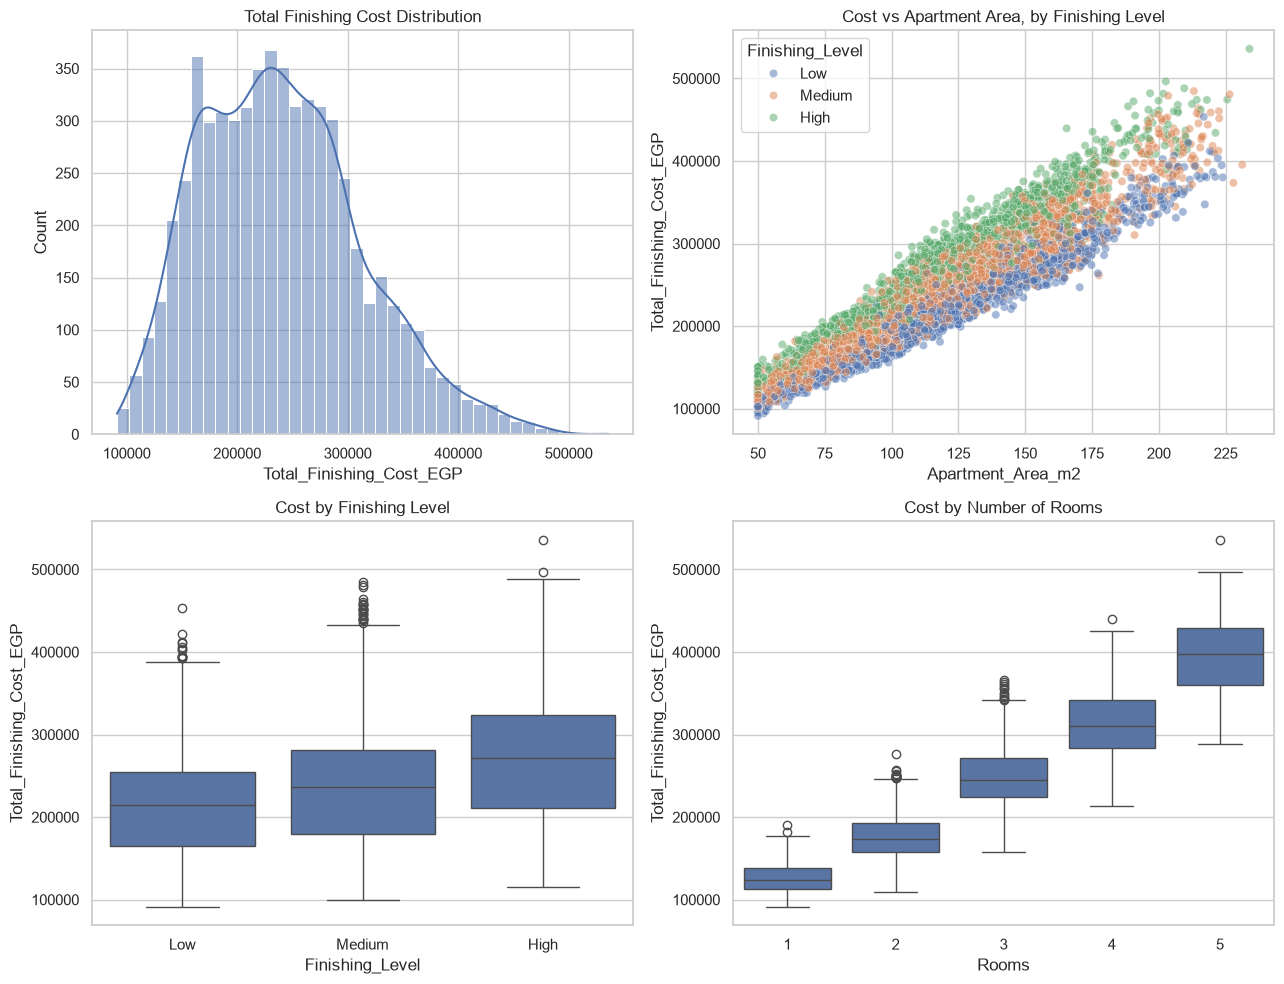

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(training_df["Total_Finishing_Cost_EGP"], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Total Finishing Cost Distribution")

sns.scatterplot(data=training_df, x="Apartment_Area_m2", y="Total_Finishing_Cost_EGP",
                 hue="Finishing_Level", alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title("Cost vs Apartment Area, by Finishing Level")

sns.boxplot(data=training_df, x="Finishing_Level", y="Total_Finishing_Cost_EGP",
            order=["Low", "Medium", "High"], ax=axes[1, 0])
axes[1, 0].set_title("Cost by Finishing Level")

sns.boxplot(data=training_df, x="Rooms", y="Total_Finishing_Cost_EGP", ax=axes[1, 1])
axes[1, 1].set_title("Cost by Number of Rooms")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_training_dataset_overview.png", dpi=120)
plt.show()

*Question: how does the total cost break down across categories, on average, and does that shift with Finishing_Level?*

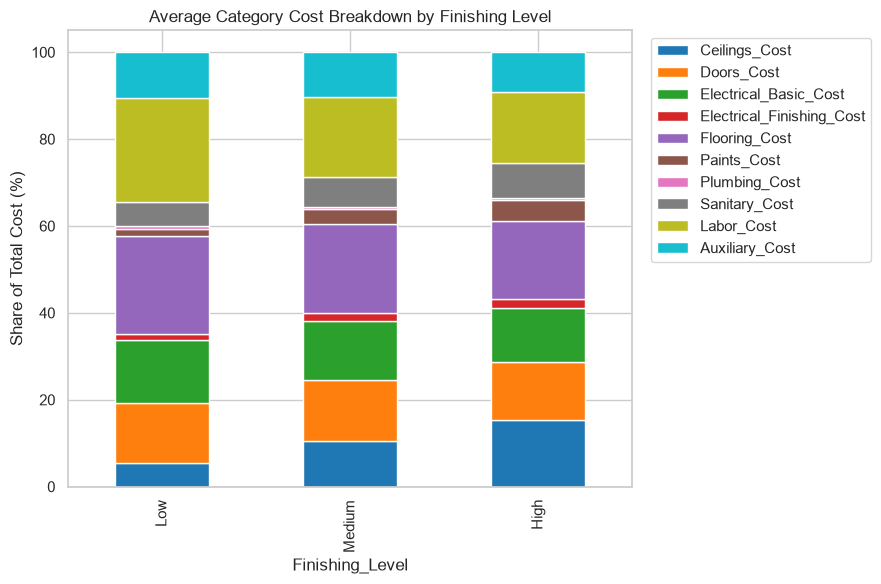

In [7]:
avg_share = (
    training_df.groupby("Finishing_Level")[CATEGORY_COST_COLUMNS]
    .mean()
    .loc[["Low", "Medium", "High"]]
)
avg_share_pct = avg_share.div(avg_share.sum(axis=1), axis=0) * 100

avg_share_pct.plot(kind="bar", stacked=True, figsize=(9, 6), colormap="tab10")
plt.ylabel("Share of Total Cost (%)")
plt.title("Average Category Cost Breakdown by Finishing Level")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_category_cost_breakdown.png", dpi=120)
plt.show()

In [8]:
avg_share_pct.round(1)

,Ceilings_Cost,Doors_Cost,Electrical_Basic_Cost,Electrical_Finishing_Cost,Flooring_Cost,Paints_Cost,Plumbing_Cost,Sanitary_Cost,Labor_Cost,Auxiliary_Cost
Finishing_Level,,,,,,,,,,
Low,5.4,13.9,14.5,1.3,22.6,1.6,0.7,5.6,24.0,10.5
Medium,10.6,14.0,13.6,1.8,20.5,3.4,0.5,7.0,18.2,10.4
High,15.4,13.2,12.5,2.1,18.0,4.7,0.5,8.2,16.1,9.3


## 6. Data Leakage Audit (Phase 9 -- mandatory)

The target is `Total_Finishing_Cost_EGP = sum(category costs)`. The category
cost columns (`Ceilings_Cost`, `Doors_Cost`, ...) therefore **reconstruct the
target almost perfectly by construction** and must NOT be used as model
inputs -- doing so would make the "prediction" problem trivial (the model
would just learn to add up numbers it was already given) and would not
reflect what is actually known before the total cost exists.

`src/scenario_generation/generate_scenarios.FEATURE_COLUMNS` is the
explicit, hand-maintained allow-list of legitimate inputs: apartment
characteristics + the overall finishing level + per-category quality
*preferences* + optional-upgrade choices + plumbing system preference. All
of these represent information a user would supply BEFORE any cost is
computed. Everything else derived during scenario generation (category
costs, the total cost) is excluded from X by construction, not by
after-the-fact column-dropping -- this cell verifies that explicitly.

In [9]:
leakage_columns = CATEGORY_COST_COLUMNS + ["Total_Finishing_Cost_EGP", "Scenario_ID"]

overlap = set(FEATURE_COLUMNS) & set(leakage_columns)
assert not overlap, f"Leakage columns found inside FEATURE_COLUMNS: {overlap}"

correlation_with_target = (
    training_df[CATEGORY_COST_COLUMNS]
    .corrwith(training_df["Total_Finishing_Cost_EGP"])
    .sort_values(ascending=False)
)
print("Correlation of each category cost with the target (excluded from X for exactly this reason):")
correlation_with_target

Correlation of each category cost with the target (excluded from X for exactly this reason):


Auxiliary_Cost               0.951845
Electrical_Basic_Cost        0.940543
Flooring_Cost                0.868115
Labor_Cost                   0.829243
Doors_Cost                   0.799549
Ceilings_Cost                0.667410
Sanitary_Cost                0.626312
Paints_Cost                  0.572792
Plumbing_Cost                0.564381
Electrical_Finishing_Cost    0.558636
dtype: float64

In [10]:
print("Model input features (X):")
for c in FEATURE_COLUMNS:
    print(" -", c)
print()
print("Target (y): Total_Finishing_Cost_EGP")
print()
print("Excluded (leakage / identifiers, kept only for reporting):")
for c in leakage_columns:
    print(" -", c)

Model input features (X):
 - Apartment_Area_m2
 - Rooms
 - Bathrooms
 - Master_Bathrooms
 - Balconies
 - Receptions
 - Finishing_Level
 - Ceilings_Quality
 - Doors_Quality
 - Electrical_Basic_Quality
 - Electrical_Finishing_Quality
 - Flooring_Quality
 - Paints_Quality
 - Plumbing_Quality
 - Sanitary_Quality
 - Include_Reception_Ceiling_Upgrade
 - Include_Reception_Chandelier
 - Include_Master_Bathroom_Upgrade
 - Plumbing_System

Target (y): Total_Finishing_Cost_EGP

Excluded (leakage / identifiers, kept only for reporting):
 - Ceilings_Cost
 - Doors_Cost
 - Electrical_Basic_Cost
 - Electrical_Finishing_Cost
 - Flooring_Cost
 - Paints_Cost
 - Plumbing_Cost
 - Sanitary_Cost
 - Labor_Cost
 - Auxiliary_Cost
 - Total_Finishing_Cost_EGP
 - Scenario_ID


## 7. Save the Training Dataset

In [11]:
training_path = TRAINING_DATA_DIR / "training_dataset.csv"
training_df.to_csv(training_path, index=False)
print("Saved", training_path, training_df.shape)

Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\data\training\training_dataset.csv (6000, 34)


In [12]:
import json

feature_config = {
    "feature_columns": FEATURE_COLUMNS,
    "target_column": "Total_Finishing_Cost_EGP",
    "category_cost_columns_excluded_from_features": CATEGORY_COST_COLUMNS,
    "n_scenarios": N_SCENARIOS,
    "random_seed": RANDOM_SEED,
}
config_path = TRAINING_DATA_DIR / "feature_config.json"
config_path.write_text(json.dumps(feature_config, indent=2), encoding="utf-8")
print("Saved", config_path)

Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\data\training\feature_config.json


In [13]:
report_path = REPORTS_DIR / "04_training_dataset_report.md"
lines = ["# Training Dataset Generation Report", ""]
lines.append("Generated by `notebooks/04_Training_Dataset_Generation.ipynb`. Do not edit by hand.")
lines.append("")
lines.append("**This is a scenario-generated / synthetic training dataset.** See")
lines.append("`src/scenario_generation/generate_scenarios.py` for the full documented")
lines.append("methodology and assumptions.")
lines.append("")
lines.append(f"- Scenarios generated: **{len(training_df)}** (seed={RANDOM_SEED})")
lines.append(f"- Feature columns: **{len(FEATURE_COLUMNS)}**")
lines.append(f"- Target: `Total_Finishing_Cost_EGP`, mean = {training_df['Total_Finishing_Cost_EGP'].mean():,.0f} EGP, "
              f"std = {training_df['Total_Finishing_Cost_EGP'].std():,.0f} EGP")
lines.append("")
lines.append("## Validation checks")
lines.append("")
lines.append(validation_table.to_markdown(index=False))
lines.append("")
lines.append("## Average category cost share by finishing level (%)")
lines.append("")
lines.append(avg_share_pct.round(1).to_markdown())
lines.append("")
lines.append("## Leakage audit")
lines.append("")
lines.append("Category cost columns correlate near-perfectly with the target by")
lines.append("construction and are therefore excluded from the model's feature set:")
lines.append("")
lines.append(correlation_with_target.to_frame("Correlation_With_Target").to_markdown())

report_path.write_text("\n".join(lines), encoding="utf-8")
print("Saved", report_path)

Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\reports\04_training_dataset_report.md
